<a href="https://colab.research.google.com/github/nomahnsfees053/sales-data-analysis/blob/main/Sales_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Sales Data Analysis**

 SALES DATA — EXPLORATORY ANALYSIS

Records   : 199
Period    : 2025-01-03  →  2025-06-29
Products  : Desk Chair, Headphones, Keyboard, Laptop, Mouse, Study Table
Categories: Electronics, Furniture

── Sample rows ──
      Date     Product    Category  Units_Sold  Unit_Price  Revenue   Month MonthName
2025-06-16 Study Table   Furniture           5        6500    32500 2025-06  Jun 2025
2025-02-21  Headphones Electronics          10        1800    18000 2025-02  Feb 2025
2025-04-18  Desk Chair   Furniture           8        4500    36000 2025-04  Apr 2025
2025-01-16  Desk Chair   Furniture           3        4500    13500 2025-01  Jan 2025
2025-06-10 Study Table   Furniture          14        6500    91000 2025-06  Jun 2025

── Descriptive statistics ──
       Units_Sold  Unit_Price     Revenue
count      199.00      199.00      199.00
mean        10.78    12045.73   118418.59
std          5.87    19662.50   217822.09
min          1.00      700.00      700.00
25%          6.00     1200.

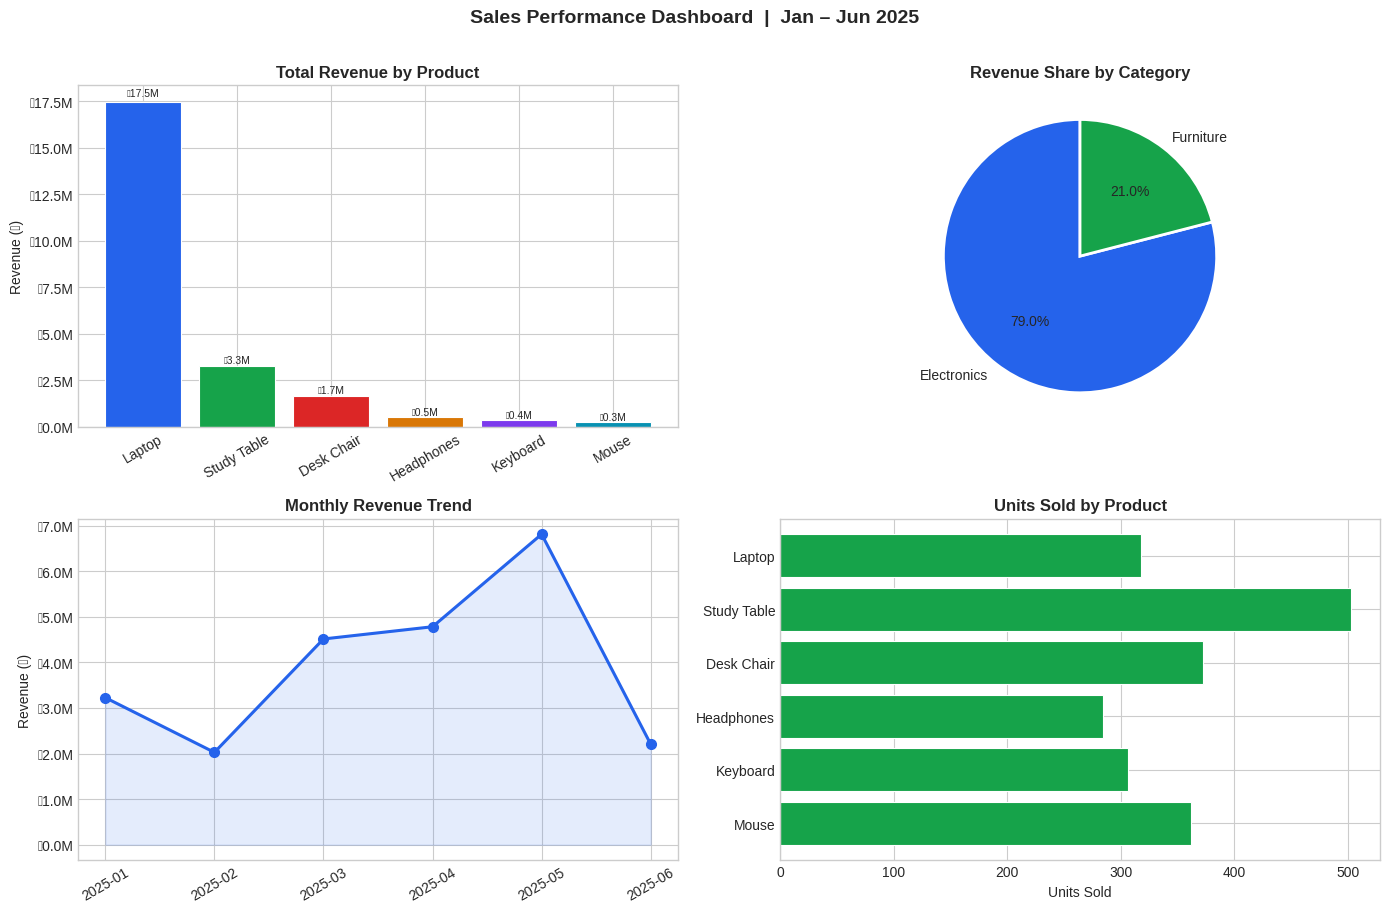

In [27]:
"""
Sales Data Analysis
====================
Author  : [Your Name]
Dataset : Sales transactions (Jan – Jun 2025)
Tools   : Python · Pandas · Matplotlib

Overview
--------
This script analyses a retail sales dataset covering Electronics and
Furniture products across six months. It covers data cleaning, exploratory
analysis, KPI extraction, and visualisation.
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


# ── Config ────────────────────────────────────────────────────────────────────

FILE   = "Data_Analysis_Project_Dataset.xlsx"
SHEET  = "SalesData"
COLORS = ["#2563EB", "#16A34A", "#DC2626", "#D97706",
          "#7C3AED", "#0891B2", "#DB2777", "#65A30D"]


# ── 1. Load & Clean ───────────────────────────────────────────────────────────

df = pd.read_excel(FILE, sheet_name=SHEET, parse_dates=["Date"])
df.columns = df.columns.str.strip()

# drop duplicates and rows with missing critical values
df.drop_duplicates(inplace=True)
df.dropna(subset=["Date", "Product", "Revenue"], inplace=True)

# derive helper columns
df["Month"]    = df["Date"].dt.to_period("M")
df["MonthName"] = df["Date"].dt.strftime("%b %Y")


# ── 2. Exploratory Overview ───────────────────────────────────────────────────

print("=" * 55)
print(" SALES DATA — EXPLORATORY ANALYSIS")
print("=" * 55)
print(f"\nRecords   : {len(df)}")
print(f"Period    : {df['Date'].min().date()}  →  {df['Date'].max().date()}")
print(f"Products  : {', '.join(sorted(df['Product'].unique()))}")
print(f"Categories: {', '.join(sorted(df['Category'].unique()))}")

print("\n── Sample rows ──")
print(df.head(5).to_string(index=False))

print("\n── Descriptive statistics ──")
print(df[["Units_Sold", "Unit_Price", "Revenue"]].describe().round(2))


# ── 3. Key Performance Indicators ────────────────────────────────────────────

total_revenue  = df["Revenue"].sum()
total_units    = df["Units_Sold"].sum()
avg_order_val  = df["Revenue"].mean()
top_product    = df.groupby("Product")["Revenue"].sum().idxmax()
best_month     = df.groupby("Month")["Revenue"].sum().idxmax()

print("\n── KPIs ──")
print(f"  Total Revenue    : ₹{total_revenue:>12,.0f}")
print(f"  Total Units Sold : {total_units:>12,}")
print(f"  Avg Order Value  : ₹{avg_order_val:>12,.0f}")
print(f"  Top Product      : {top_product}")
print(f"  Best Month       : {best_month}")


# ── 4. Grouped Summaries ──────────────────────────────────────────────────────

# by product
product_summary = (
    df.groupby("Product")
    .agg(Total_Revenue=("Revenue", "sum"),
         Total_Units=("Units_Sold", "sum"),
         Avg_Order=("Revenue", "mean"),
         Transactions=("Revenue", "count"))
    .sort_values("Total_Revenue", ascending=False)
    .round(0)
)

# by category
category_summary = (
    df.groupby("Category")
    .agg(Total_Revenue=("Revenue", "sum"),
         Total_Units=("Units_Sold", "sum"))
    .round(0)
)

# monthly
monthly_summary = (
    df.groupby("Month")
    .agg(Revenue=("Revenue", "sum"),
         Units=("Units_Sold", "sum"),
         Transactions=("Revenue", "count"))
    .reset_index()
)

print("\n── Revenue by Product ──")
print(product_summary.to_string())

print("\n── Revenue by Category ──")
print(category_summary.to_string())

print("\n── Monthly Trend ──")
print(monthly_summary.to_string(index=False))


# ── 5. Correlation ────────────────────────────────────────────────────────────

print("\n── Correlation Matrix ──")
print(df[["Units_Sold", "Unit_Price", "Revenue"]].corr().round(3))


# ── 6. Visualisations ─────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Sales Performance Dashboard  |  Jan – Jun 2025",
             fontsize=14, fontweight="bold", y=1.01)

months_str = [str(m) for m in monthly_summary["Month"]]

# 6a – Revenue by Product
ax = axes[0, 0]
bars = ax.bar(product_summary.index, product_summary["Total_Revenue"],
              color=COLORS[:len(product_summary)], edgecolor="white", linewidth=0.8)
ax.set_title("Total Revenue by Product", fontweight="bold")
ax.set_ylabel("Revenue (₹)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x/1e6:.1f}M"))
ax.tick_params(axis="x", rotation=30)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h * 1.01,
            f"₹{h/1e6:.1f}M", ha="center", va="bottom", fontsize=7.5)

# 6b – Category Pie
ax = axes[0, 1]
category_summary["Total_Revenue"].plot(
    kind="pie", ax=ax, autopct="%1.1f%%",
    colors=COLORS[:2], startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2})
ax.set_title("Revenue Share by Category", fontweight="bold")
ax.set_ylabel("")

# 6c – Monthly Revenue Line
ax = axes[1, 0]
ax.plot(months_str, monthly_summary["Revenue"],
        marker="o", color=COLORS[0], linewidth=2.2, markersize=7)
ax.fill_between(months_str, monthly_summary["Revenue"], alpha=0.12, color=COLORS[0])
ax.set_title("Monthly Revenue Trend", fontweight="bold")
ax.set_ylabel("Revenue (₹)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x/1e6:.1f}M"))
ax.tick_params(axis="x", rotation=30)

# 6d – Units Sold by Product
ax = axes[1, 1]
ax.barh(product_summary.index[::-1], product_summary["Total_Units"][::-1],
        color=COLORS[1], edgecolor="white", linewidth=0.8)
ax.set_title("Units Sold by Product", fontweight="bold")
ax.set_xlabel("Units Sold")

plt.tight_layout()
plt.savefig("sales_dashboard.png", dpi=150, bbox_inches="tight")
print("\n[✓] Dashboard saved → sales_dashboard.png")
plt.show()